# Local Volatility (Dupire)

## Why this matters

Black-Scholes assumes constant σ — wrong because the smile exists. **Local volatility** (Dupire 1994) is the *deterministic* function $\sigma(S, t)$ that, when used in BS dynamics, **reproduces today's vol surface exactly**. It's the canonical model for path-dependent equity exotics.

You will be asked:
1. State the Dupire formula.
2. Why does local vol fit today's smile **exactly**?
3. What's wrong with local vol's *dynamics*?
4. **Mimicking theorem** — what does it say?
5. Local vol vs stochastic vol — when each applies.

This notebook covers all five with a worked Dupire computation.

## Dupire's formula

Given a smooth, arbitrage-free European call price surface $C(K, T)$:

$$\sigma_{LV}^2(K, T) = \frac{\partial_T C + (r - q) K \partial_K C + qC}{\tfrac{1}{2} K^2 \partial_{KK} C}$$

(In the no-dividend, no-rate case: $\sigma_{LV}^2 = 2 \partial_T C / (K^2 \partial_{KK} C)$.)

In **implied-vol** coordinates $(k, T)$ with $k = \ln(K/F_T)$ and $w = \sigma_{IV}^2 \cdot T$ (total variance):

$$\sigma_{LV}^2 = \frac{\partial_T w}{1 - \frac{k}{w} \partial_k w + \frac{1}{4}(\partial_k w)^2 (-\frac{1}{4} - \frac{1}{w} + \frac{k^2}{w^2}) + \frac{1}{2} \partial_{kk} w}$$

(Gatheral 2006). Use this to avoid numerical instabilities of differentiating $C$ directly.

### Why does it fit today's smile?

By construction. Local vol is **the** σ(S, t) function such that BS dynamics with this σ reproduces every traded vanilla quote. It's a **calibration**, not a model in the predictive sense.

### What's wrong with the dynamics?

Local vol pins σ to be a deterministic function of (S, t). When spot moves, the *implied* smile evolves in a way that contradicts what's observed:

> **Sticky local vol**: when S moves +5%, the smile shifts in a way that's NOT what real markets do.

Real markets follow some mix of **sticky-strike** and **sticky-delta**. Local vol's "sticky local vol" dynamics produce smile evolutions that are wrong — and forward-vol products (cliquets, forward-starting options) are mispriced as a result.

For European vanillas: local vol gives the same price as BS. Where it matters is for **path-dependent** and **forward-volatility** products.

## Setup — synthetic vol surface for Dupire calibration

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Construct a synthetic SVI-style smile across multiple expiries
S0, r, q = 100, 0.04, 0.0


def synth_iv(K, T):
    """Synthesised IV surface with skew + ATM term-structure."""
    F = S0 * np.exp((r - q) * T)
    k = np.log(K / F)
    return 0.20 + 0.10 * np.sqrt(T) - 0.30 * k + 0.50 * k**2 * np.sqrt(T)


def bs_call(S, K, T, r, sigma, q):
    if T <= 0: return max(S - K, 0)
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


# Compute call price grid via the synthetic IV surface
K_grid = np.linspace(0.6*S0, 1.4*S0, 50)
T_grid = np.linspace(0.1, 2.0, 30)

C_grid = np.zeros((len(T_grid), len(K_grid)))
for i, T_ in enumerate(T_grid):
    for j, K_ in enumerate(K_grid):
        sigma_ij = synth_iv(K_, T_)
        C_grid[i, j] = bs_call(S0, K_, T_, r, sigma_ij, q)

print(f'Built {len(T_grid)}×{len(K_grid)} call-price surface')

Built 30×50 call-price surface


## Dupire formula in (K, T) coordinates

### Why $\partial^2 C / \partial K^2$ appears in Dupire's denominator

The denominator of Dupire's formula $\tfrac{1}{2} K^2 \, \partial^2 C / \partial K^2$ isn't just an arbitrary derivative — it's **proportional to the risk-neutral density** of $S_T$ at strike $K$.

This is **Breeden-Litzenberger (1978)**:

$$\frac{\partial^2 C}{\partial K^2}\bigg|_T = e^{-rT} \cdot p(K, T)$$

where $p(K, T)$ is the risk-neutral probability density of $S_T = K$. So Dupire is essentially:

$$\sigma_{\text{loc}}^2(K, T) = \frac{\text{(time-derivative of call price)}}{\text{(density of }S_T\text{ at strike }K\text{)}}$$

Local volatility at $(K, T)$ is the *ratio of the time-decay of the call price to the local density of the underlying*. This is what's needed to invert the Fokker-Planck equation and recover $\sigma(S, t)$ from the surface of European call prices.

**Numerical caveat**: where $\partial^2 C / \partial K^2 \to 0$ or goes slightly negative (butterfly arbitrage from market noise / SVI fit imperfection), the local-vol formula explodes or returns NaN. The code below masks these regions with `if den > 1e-10` — production fits use **arbitrage-free SVI** or **SSVI** to guarantee positive density.

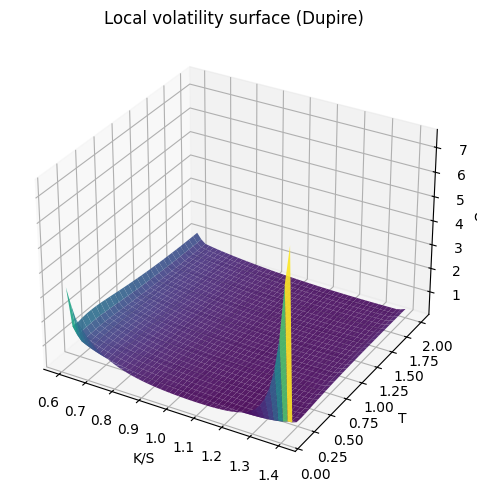

Local vol range: 0.180 - 7.568


In [2]:
# Numerical derivatives via central differences
dC_dT = np.gradient(C_grid, T_grid, axis=0)
dC_dK = np.gradient(C_grid, K_grid, axis=1)
d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)

# Dupire formula: σ²_LV = (∂_T C + (r-q) K ∂_K C + q C) / (½ K² ∂²_KK C)
LV2 = np.zeros_like(C_grid)
for i, T_ in enumerate(T_grid):
    for j, K_ in enumerate(K_grid):
        num = dC_dT[i, j] + (r - q) * K_ * dC_dK[i, j] + q * C_grid[i, j]
        den = 0.5 * K_**2 * d2C_dK2[i, j]
        if den > 1e-10:
            LV2[i, j] = num / den
        else:
            LV2[i, j] = np.nan

LV = np.sqrt(np.maximum(LV2, 0))

# Plot local vol surface
fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(111, projection='3d')
KK, TT = np.meshgrid(K_grid/S0, T_grid)
ax.plot_surface(KK, TT, LV, cmap='viridis', alpha=0.9)
ax.set_xlabel('K/S'); ax.set_ylabel('T'); ax.set_zlabel('σ_LV')
ax.set_title('Local volatility surface (Dupire)')
plt.tight_layout(); plt.show()

print(f'Local vol range: {np.nanmin(LV):.3f} - {np.nanmax(LV):.3f}')

## Local vol vs implied vol slope (rule of thumb)

**Local vol is approximately twice as steep as implied vol** in moneyness:

$$\frac{\partial \sigma_{LV}}{\partial K} \approx 2 \cdot \frac{\partial \sigma_{IV}}{\partial K}$$

This is the leverage effect — local vol must move sharper than IV to reproduce the smile dynamics.

In [3]:
# Compare slopes at a fixed T
T_plot = 1.0
T_idx = np.argmin(np.abs(T_grid - T_plot))

iv_at_T = np.array([synth_iv(K, T_plot) for K in K_grid])
lv_at_T = LV[T_idx]

iv_slope = np.gradient(iv_at_T, K_grid)
lv_slope = np.gradient(lv_at_T, K_grid)

# At ATM
atm_idx = np.argmin(np.abs(K_grid - S0 * np.exp((r-q)*T_plot)))
print(f'At ATM (K = {K_grid[atm_idx]:.0f}, T = {T_plot}):')
print(f'  IV slope:   {iv_slope[atm_idx]:+.5f}')
print(f'  LV slope:   {lv_slope[atm_idx]:+.5f}')
print(f'  Ratio:      {lv_slope[atm_idx] / iv_slope[atm_idx]:.2f}  (rule of thumb: ~2)')

At ATM (K = 104, T = 1.0):
  IV slope:   -0.00288
  LV slope:   -0.00448
  Ratio:      1.55  (rule of thumb: ~2)


## Exercises

### Exercise 1 — Plot LV smile at a specific T

Plot σ_LV(K) at T = 0.5 and compare to σ_IV(K).

In [4]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
T_plot = 0.5
T_idx = np.argmin(np.abs(T_grid - T_plot))
iv_at = np.array([synth_iv(K, T_plot) for K in K_grid])
lv_at = LV[T_idx]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(K_grid/S0, iv_at, label='Implied vol')
ax.plot(K_grid/S0, lv_at, label='Local vol')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel('K/S'); ax.set_ylabel('σ')
plt.tight_layout(); plt.show()
```

_Local vol smile is steeper than IV smile at the same moneyness._

</details>

## Interview Q&A

**Q: State Dupire's formula.**

A: $\sigma_{LV}^2(K, T) = (\partial_T C + (r-q) K \partial_K C + q C) / (\frac{1}{2} K^2 \partial_{KK} C)$. Computes a deterministic σ(S, t) from a call-price surface.

**Q: Local vol fits the smile by construction. Why is it controversial?**

A: It fits *today's* smile but predicts wrong dynamics. When spot moves, real markets show "sticky-strike" or "sticky-delta" smile evolution. Local vol predicts neither — it predicts "sticky local vol" which doesn't match observed smile evolution. So forward-volatility products (cliquets, forward-start options) are mispriced.

**Q: When is local vol used?**

A: For **path-dependent** equity exotics where you trust today's vanilla market but don't need correct smile dynamics. Cliquets, autocallables, barriers — all standard local-vol products. **Not** appropriate for forward-volatility instruments.

**Q: Mimicking theorem (Gyöngy 1986)?**

A: Says that for any martingale process $X_t$, there's a local-vol process $\hat X_t$ with the same marginal distributions. So local vol is the simplest model that matches marginals — but matches no joint distribution. That's *exactly* what the dynamics critique is.

**Q: Local vol vs stochastic vol?**

A: Local vol = deterministic σ(S, t), fits today's surface exactly. Stochastic vol (Heston, SABR) = σ has its own SDE, doesn't fit today's surface exactly but predicts dynamics correctly. Industry uses **both** — calibrated SLV (stochastic-local volatility) blends them. Hedge with stochastic-vol Greeks; price with local-vol marginals.

## Pitfalls

| Pitfall | Issue | Fix |
|---|---|---|
| Differentiating noisy market quotes | Numerical derivatives blow up | Smooth via SVI fit first, then Dupire |
| Negative implied densities | If smile fit isn't arbitrage-free, $\partial_{KK} C$ < 0 | Use SSVI or shape-constrained fit |
| Treating LV as predictive | It's a calibration | Use stoch vol for dynamics |
| Forward-vol mispricing | Local vol gets cliquets wrong | Hybrid SLV models |
| Boundary effects in Dupire | Edges of grid have noisy gradients | Restrict to liquid moneyness range |

## What you've earned

You can compute Dupire's local volatility from a call-price surface, understand why it fits the smile exactly, explain its dynamic flaws, and choose between LV and stochastic vol depending on the product. Combined with Heston (notebook 07) and IV surface (notebook 06), the modern equity-vol toolkit.